In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("superstore_sales.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,1/6/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2.0,0.0,106.140,35.46,Medium,2011.0
1,IN-2011-47883,1/1/2011,1/8/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3.0,0.1,36.036,9.72,Medium,2011.0
2,HU-2011-1220,1/1/2011,1/5/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4.0,0.0,29.640,8.17,High,2011.0
3,IT-2011-3647632,1/1/2011,1/5/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3.0,0.5,-26.055,4.82,High,2011.0
4,IN-2011-47883,1/1/2011,1/8/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5.0,0.1,37.770,4.70,Medium,2011.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29806 entries, 0 to 29805
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        29806 non-null  object 
 1   order_date      29806 non-null  object 
 2   ship_date       29806 non-null  object 
 3   ship_mode       29806 non-null  object 
 4   customer_name   29806 non-null  object 
 5   segment         29805 non-null  object 
 6   state           29805 non-null  object 
 7   country         29805 non-null  object 
 8   market          29805 non-null  object 
 9   region          29805 non-null  object 
 10  product_id      29805 non-null  object 
 11  category        29805 non-null  object 
 12  sub_category    29805 non-null  object 
 13  product_name    29805 non-null  object 
 14  sales           29805 non-null  object 
 15  quantity        29805 non-null  float64
 16  discount        29805 non-null  float64
 17  profit          29805 non-null 

In [4]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,1
state,1
country,1
market,1
region,1


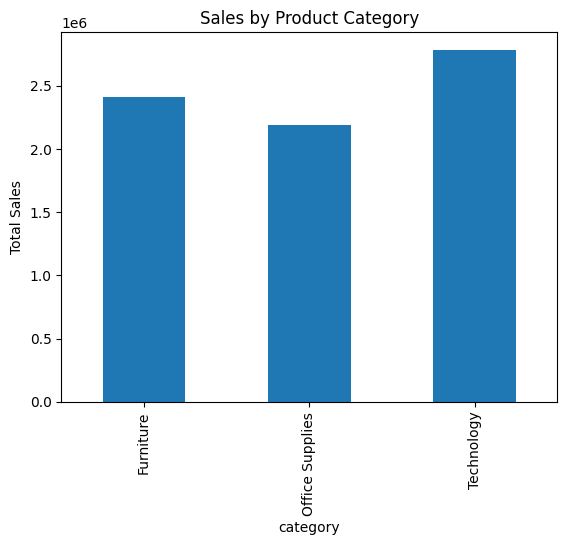

In [7]:
df['sales'] = df['sales'].astype(str).str.replace(',', '').astype(float)
category_sales = df.groupby("category")["sales"].sum()

category_sales.plot(kind="bar")
plt.title("Sales by Product Category")
plt.ylabel("Total Sales")
plt.show()

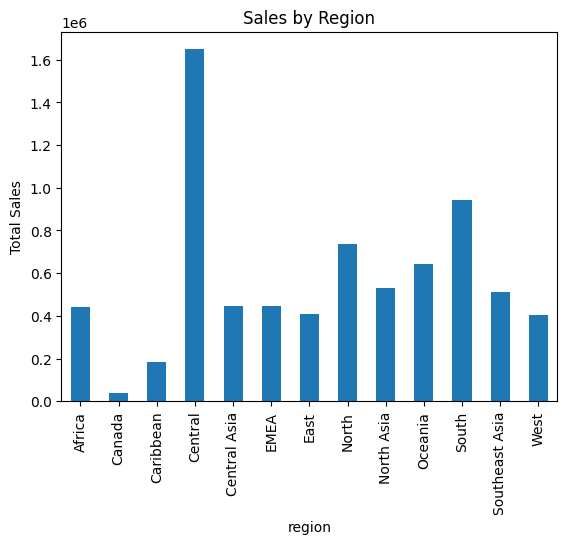

In [9]:
region_sales = df.groupby("region")["sales"].sum()

region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.show()

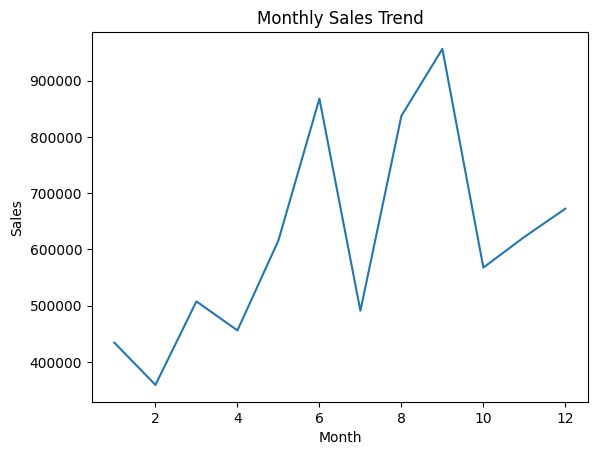

In [11]:
df["order_date"] = pd.to_datetime(df["order_date"])

monthly_sales = df.groupby(df["order_date"].dt.month)["sales"].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

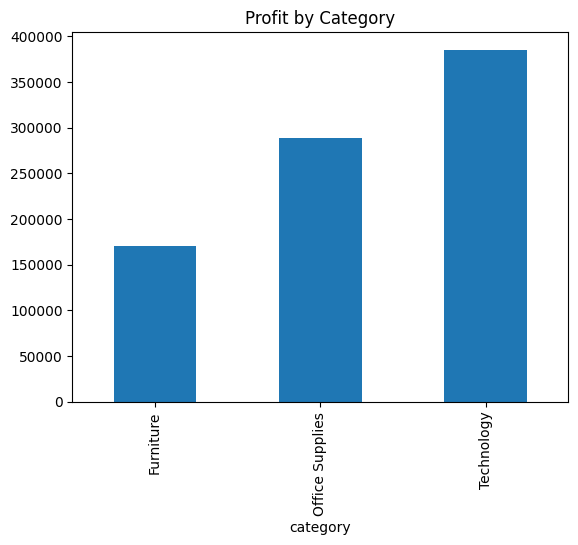

In [13]:
df.groupby("category")["profit"].sum().plot(kind="bar")

plt.title("Profit by Category")
plt.show()

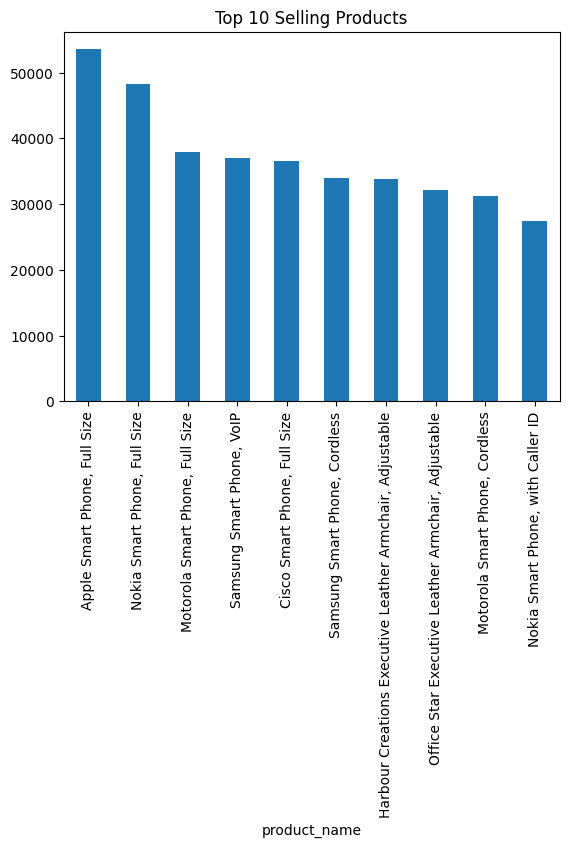

In [15]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Selling Products")
plt.show()